# Assignment 4: Training a DCGAN with the Fashion-MNIST Dataset

**Objective:** To explore the training process of a Deep Convolutional Generative Adversarial Network (DCGAN) and observe how the generator and discriminator develop over time using the Fashion-MNIST dataset.

## Step 1: Import the Required Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Set the Main Parameters

All required hyperparameters, including the dimension of the noise vector, are specified directly in this section.

In [3]:
# Basic parameters
NOISE_SIZE = 100       # size of the noise vector (input to generator)
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 0.0002
IMAGE_SIZE = 28        # Fashion-MNIST images are 28x28
CHANNELS = 1         # grayscale

# Fixed noise vector for consistent image saving every 5 epochs
FIXED_NOISE = torch.randn(16, NOISE_SIZE, 1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

FIXED_NOISE = FIXED_NOISE.to(device)

Using device: cuda


## Step 3: Load the Fashion-MNIST Dataset

The images are scaled to the interval **[-1, +1]**. This is necessary because the generator's final activation function is **tanh**, which produces output values within the same range.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # brings pixel values from [0,1] to [-1,+1]
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"Total training images: {len(dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 1.97MB/s]

Total training images: 60000


## Step 4: Display the Original Images

A 4 × 4 arrangement of genuine Fashion-MNIST images is shown before the training process starts.

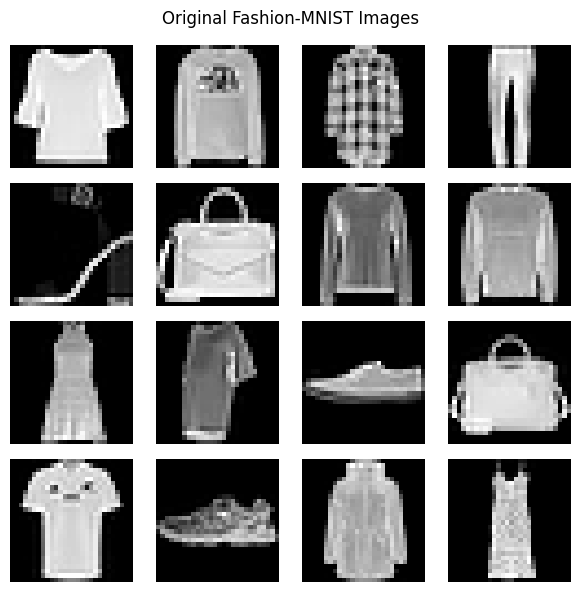

In [5]:
# Grab one batch
real_images, labels = next(iter(dataloader))

# Show first 16 images in a 4x4 grid
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # denormalize from [-1,+1] back to [0,1] for display
    img = real_images[i].squeeze().numpy()
    img = (img + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Original Fashion-MNIST Images')
plt.tight_layout()
plt.show()

## Step 5: Construct the Generator

The generator receives a **random noise vector** containing 100 values. It then applies **transposed convolutional layers** to expand this input into a 28 × 28 image.

As the transposed convolution layers operate, the spatial dimensions increase while the number of filters decreases.

The last layer uses the **tanh** activation function, producing pixel values in the range [-1, +1].

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # input: noise vector (100, 1, 1)
            nn.ConvTranspose2d(100, 256, kernel_size=4, stride=1, padding=0),  # → (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # → (128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # → (64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=3),     # → (1, 28, 28)
            nn.Tanh()   # output in range [-1, +1] to match normalized dataset
        )

    def forward(self, x):
        return self.model(x)


generator = Generator().to(device)
print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(3, 3))
    (10): Tanh()
  )
)


## Step 6: Evaluate the Generator Before Training

The fixed noise vector is passed through the generator before it has learned anything. The resulting images are expected to appear as random patterns without identifiable shapes, since the model is still untrained.

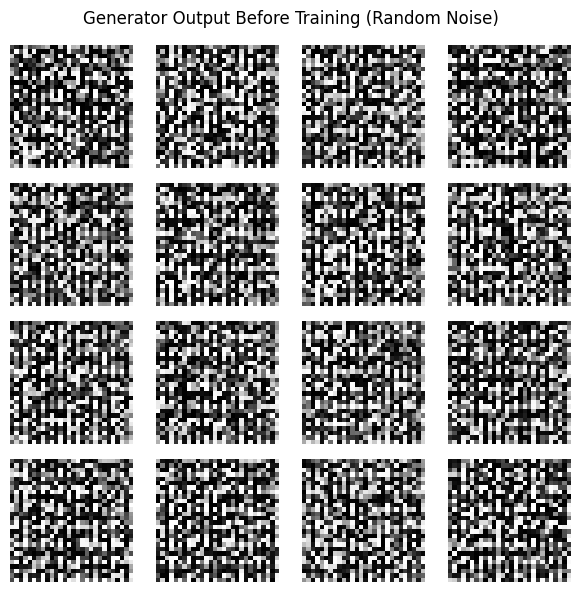

In [7]:
# Pass fixed noise through untrained generator
with torch.no_grad():
    test_output = generator(FIXED_NOISE)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = test_output[i].squeeze().cpu().numpy()
    img = (img + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Generator Output Before Training (Random Noise)')
plt.tight_layout()
plt.show()

## Step 7: Construct the Discriminator

The discriminator receives a 28 × 28 image and determines whether it is **real (1) or fake (0)**.

It applies regular **convolutional layers** to reduce the image dimensions and uses a final **sigmoid** activation to produce a probability between 0 and 1.

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # input: (1, 28, 28)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),    # → (64, 14, 14)
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # → (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # → (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),    # → (1, 1, 1)
            nn.Sigmoid()   # output: probability of image being real
        )

    def forward(self, x):
        return self.model(x).view(-1, 1).squeeze(1)


discriminator = Discriminator().to(device)
print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1))
    (9): Sigmoid()
  )
)


## Step 8: Specify the Loss Function and Optimizer

The model uses Binary Cross Entropy (**BCELoss**) as its loss function. The discriminator is trained to assign a value of 1 to genuine images and 0 to generated images. In contrast, the generator is trained to make the discriminator identify its generated images as real by predicting 1.

In [9]:
loss_function = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(),     lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

print("Loss function and optimizers defined.")

Loss function and optimizers defined.


## Step 9 and Step 10: Train the Models for 25 Epochs

The models are updated in the following sequence during every training iteration:

1. **Train the discriminator first** — use real images with label 1 and generated images with label 0.
2. **Train the generator afterward** — attempt to deceive the discriminator so that generated images receive label 1.

A 4 × 4 grid of generated samples is stored after every 5 epochs.

Epoch [1/25]  Discriminator Loss: 0.7307  Generator Loss: 2.2266
Epoch [2/25]  Discriminator Loss: 0.9400  Generator Loss: 1.5639
Epoch [3/25]  Discriminator Loss: 1.0049  Generator Loss: 1.3880
Epoch [4/25]  Discriminator Loss: 1.0042  Generator Loss: 1.4044
Epoch [5/25]  Discriminator Loss: 0.9734  Generator Loss: 1.4578


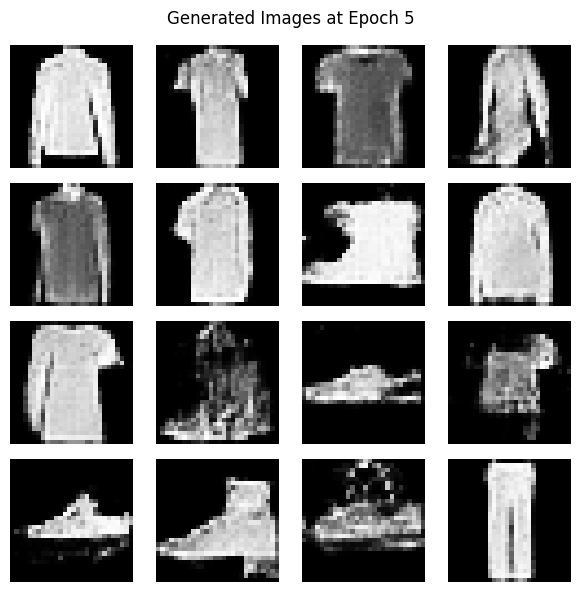

Saved image grid for epoch 5
Epoch [6/25]  Discriminator Loss: 0.9537  Generator Loss: 1.4911
Epoch [7/25]  Discriminator Loss: 0.9396  Generator Loss: 1.5242
Epoch [8/25]  Discriminator Loss: 0.9204  Generator Loss: 1.5646
Epoch [9/25]  Discriminator Loss: 0.8977  Generator Loss: 1.6085
Epoch [10/25]  Discriminator Loss: 0.8883  Generator Loss: 1.6406


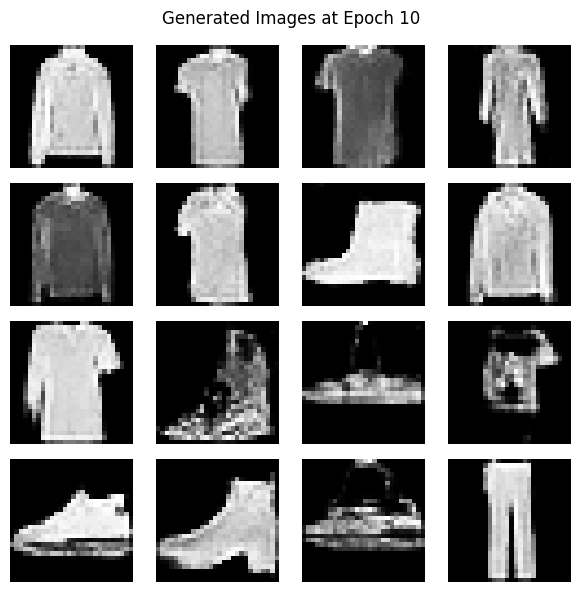

Saved image grid for epoch 10
Epoch [11/25]  Discriminator Loss: 0.8703  Generator Loss: 1.6731
Epoch [12/25]  Discriminator Loss: 0.8327  Generator Loss: 1.7348
Epoch [13/25]  Discriminator Loss: 0.8195  Generator Loss: 1.7686
Epoch [14/25]  Discriminator Loss: 0.8097  Generator Loss: 1.8002
Epoch [15/25]  Discriminator Loss: 0.7745  Generator Loss: 1.8673


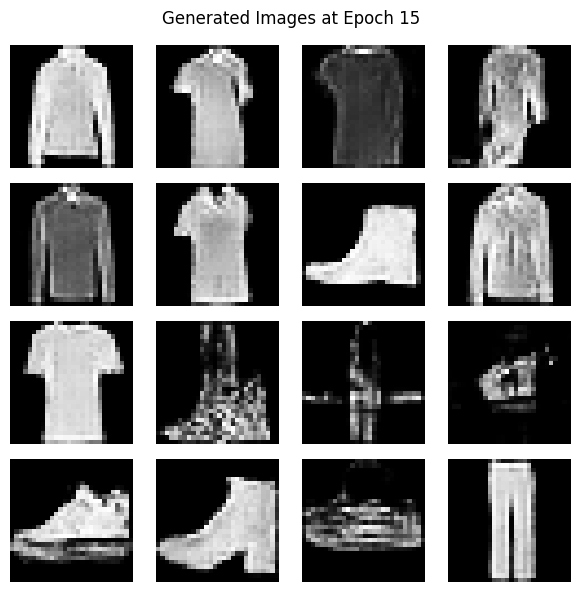

Saved image grid for epoch 15
Epoch [16/25]  Discriminator Loss: 0.7631  Generator Loss: 1.8939
Epoch [17/25]  Discriminator Loss: 0.7786  Generator Loss: 1.9130
Epoch [18/25]  Discriminator Loss: 0.7305  Generator Loss: 1.9546
Epoch [19/25]  Discriminator Loss: 0.7134  Generator Loss: 2.0088
Epoch [20/25]  Discriminator Loss: 0.7490  Generator Loss: 2.0157


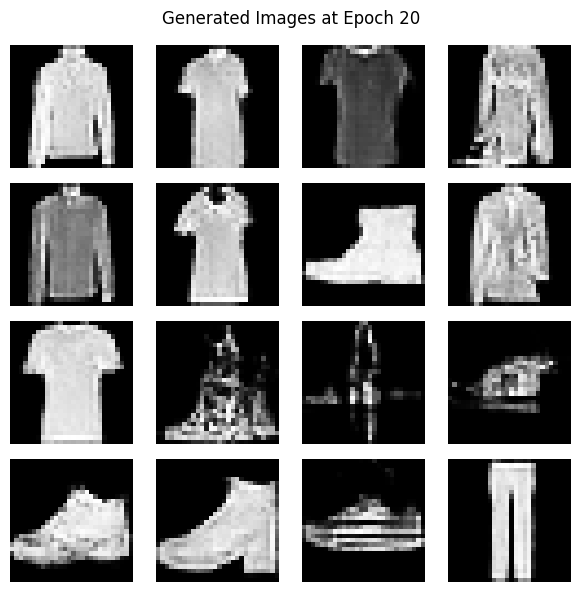

Saved image grid for epoch 20
Epoch [21/25]  Discriminator Loss: 0.6839  Generator Loss: 2.0717
Epoch [22/25]  Discriminator Loss: 0.6909  Generator Loss: 2.0988
Epoch [23/25]  Discriminator Loss: 0.6666  Generator Loss: 2.1412
Epoch [24/25]  Discriminator Loss: 0.6526  Generator Loss: 2.1954
Epoch [25/25]  Discriminator Loss: 0.6459  Generator Loss: 2.2231


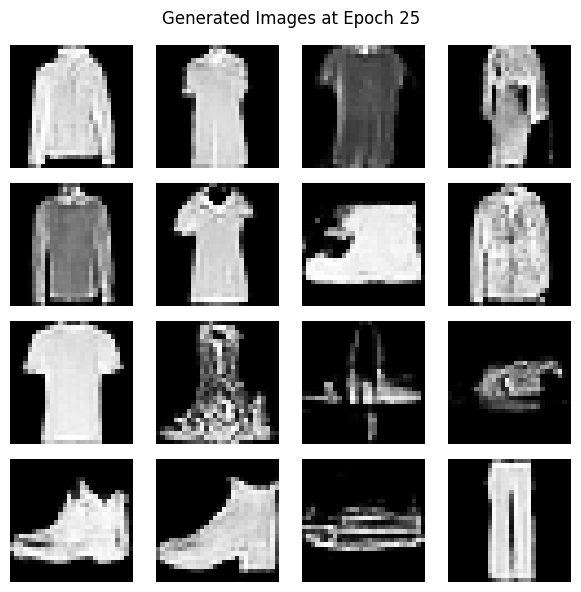

Saved image grid for epoch 25


In [10]:
G_losses = []   # store generator loss per epoch
D_losses = []   # store discriminator loss per epoch

for epoch in range(1, EPOCHS + 1):

    g_loss_epoch = 0
    d_loss_epoch = 0

    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size  = real_images.size(0)

        real_labels = torch.ones(batch_size).to(device)   # 1 for real
        fake_labels = torch.zeros(batch_size).to(device)  # 0 for fake

        # -------- Train Discriminator --------
        optimizer_D.zero_grad()

        # loss on real images
        output_real = discriminator(real_images)
        loss_real = loss_function(output_real, real_labels)

        # generate fake images
        noise = torch.randn(batch_size, NOISE_SIZE, 1, 1).to(device)
        fake_images = generator(noise)

        # loss on fake images
        output_fake = discriminator(fake_images.detach())
        loss_fake   = loss_function(output_fake, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D.step()

        # -------- Train Generator --------
        optimizer_G.zero_grad()

        # generator wants discriminator to say fake images are real (label=1)
        output_fake_for_g = discriminator(fake_images)
        g_loss = loss_function(output_fake_for_g, real_labels)

        g_loss.backward()
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    # average loss per epoch
    avg_g = g_loss_epoch / len(dataloader)
    avg_d = d_loss_epoch / len(dataloader)

    G_losses.append(avg_g)
    D_losses.append(avg_d)

    print(f"Epoch [{epoch}/{EPOCHS}]  Discriminator Loss: {avg_d:.4f}  Generator Loss: {avg_g:.4f}")

    # -------- Save 4x4 image grid every 5 epochs --------
    if epoch % 5 == 0:
        with torch.no_grad():
            generated = generator(FIXED_NOISE)

        plt.figure(figsize=(6, 6))
        for i in range(16):
            plt.subplot(4, 4, i+1)
            img = generated[i].squeeze().cpu().numpy()
            img = (img + 1) / 2
            plt.imshow(img, cmap='gray')
            plt.axis('off')
        plt.suptitle(f'Generated Images at Epoch {epoch}')
        plt.tight_layout()
        plt.savefig(f'epoch_{epoch}.png')
        plt.show()
        print(f"Saved image grid for epoch {epoch}")

## Step 12: Generate Images from a Random Noise Vector

After training has finished, a fresh random noise vector is used to create another collection of generated images.

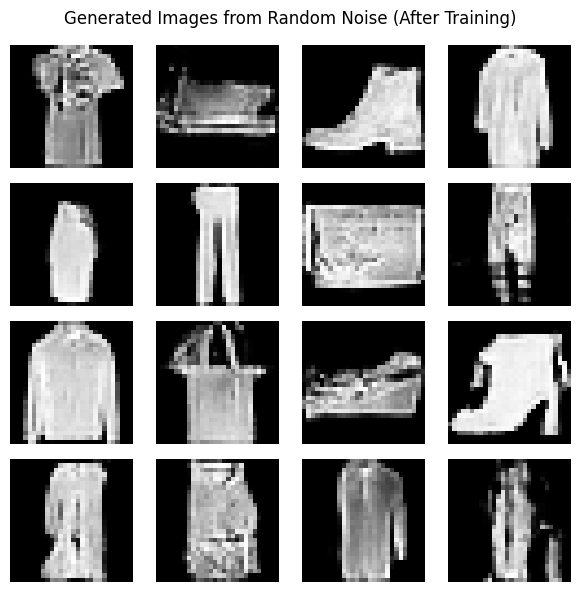

In [11]:
# Generate images from a brand new random noise vector
random_noise = torch.randn(16, NOISE_SIZE, 1, 1).to(device)

with torch.no_grad():
    random_output = generator(random_noise)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = random_output[i].squeeze().cpu().numpy()
    img = (img + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Images from Random Noise (After Training)')
plt.tight_layout()
plt.show()

## Step 13: Visualize the Generator and Discriminator Losses

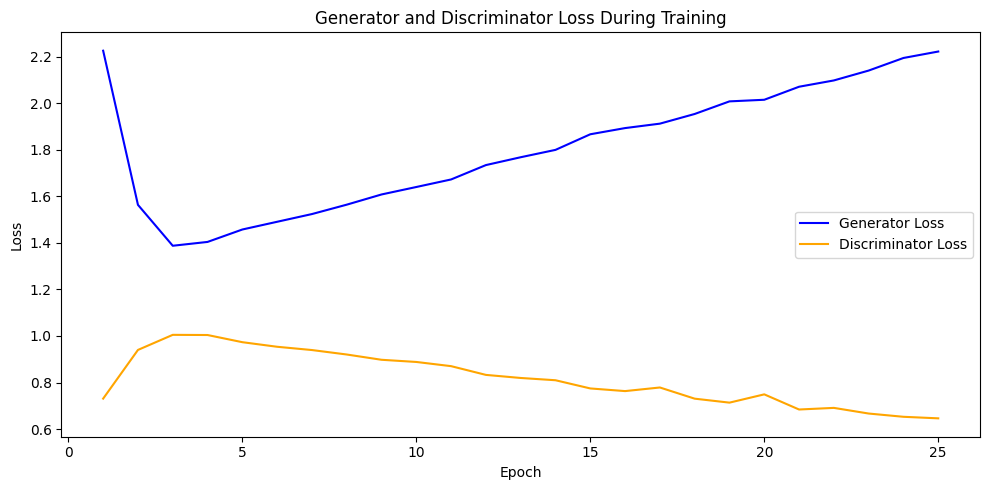

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), G_losses, label='Generator Loss',     color='blue')
plt.plot(range(1, EPOCHS+1), D_losses, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator and Discriminator Loss During Training')
plt.legend()
plt.tight_layout()
plt.show()

---

## Observations

**1. What differences can be noticed between epoch 5 and epoch 25?**

At epoch 5, the generated samples begin to resemble recognizable clothing categories such as shirts, footwear, and trousers, although the boundaries remain unclear and some random noise is visible. By epoch 25, the clothing outlines appear more distinct and the images are generally sharper. The contrast between the objects and the background also improves, with darker background regions. The range of clothing types stays relatively similar across the epochs, suggesting that the generator has learned to represent several categories.

**2. Is there any evidence of instability during training?**

Yes. The loss plot indicates a noticeable imbalance between the two networks. The discriminator loss, shown in orange, increases from approximately 0.73 to nearly 1.0 during the first three epochs, and then gradually falls to about 0.64 by epoch 25. This suggests that the discriminator becomes more effective at distinguishing generated images from real ones.

The generator loss, represented in blue, decreases quickly from around 2.22 to 1.39 in the first three epochs, but then rises steadily and returns to approximately 2.22 by epoch 25. This opposite movement—where the discriminator improves while the generator faces increasing difficulty—indicates possible instability or an imbalance in the adversarial training process.